# Notebook 5: Calibration
**PURPOSE:** Make predicted probabilities trustworthy. Critical for betting odds accuracy.

In [1]:
import os
project_root = r"C:\Users\srich\OneDrive\Desktop\prediction-model"
os.chdir(project_root)
print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: C:\Users\srich\OneDrive\Desktop\prediction-model


In [2]:
import pandas as pd
import numpy as np
import pickle, json, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

print('Libraries loaded ✅')

Libraries loaded ✅


In [3]:
train_df = pd.read_csv('data/processed/training_data.csv')
test_df = pd.read_csv('data/processed/test_data.csv')
with open('model/feature_names.json') as f:
    feature_cols = json.load(f)

X_train = train_df[feature_cols]
y_train = train_df['result']
X_test = test_df[feature_cols]
y_test = test_df['result']

tuned_models = {}
for name in ['xgboost', 'lightgbm', 'random_forest']:
    path = f'model/tuned_{name}.pkl'
    try:
        with open(path, 'rb') as f:
            tuned_models[name] = pickle.load(f)
        print(f'✅ Loaded: {name}')
    except:
        print(f'❌ Missing: {path}')

✅ Loaded: xgboost
✅ Loaded: lightgbm
✅ Loaded: random_forest


## 5.1 Pre-Calibration Curves

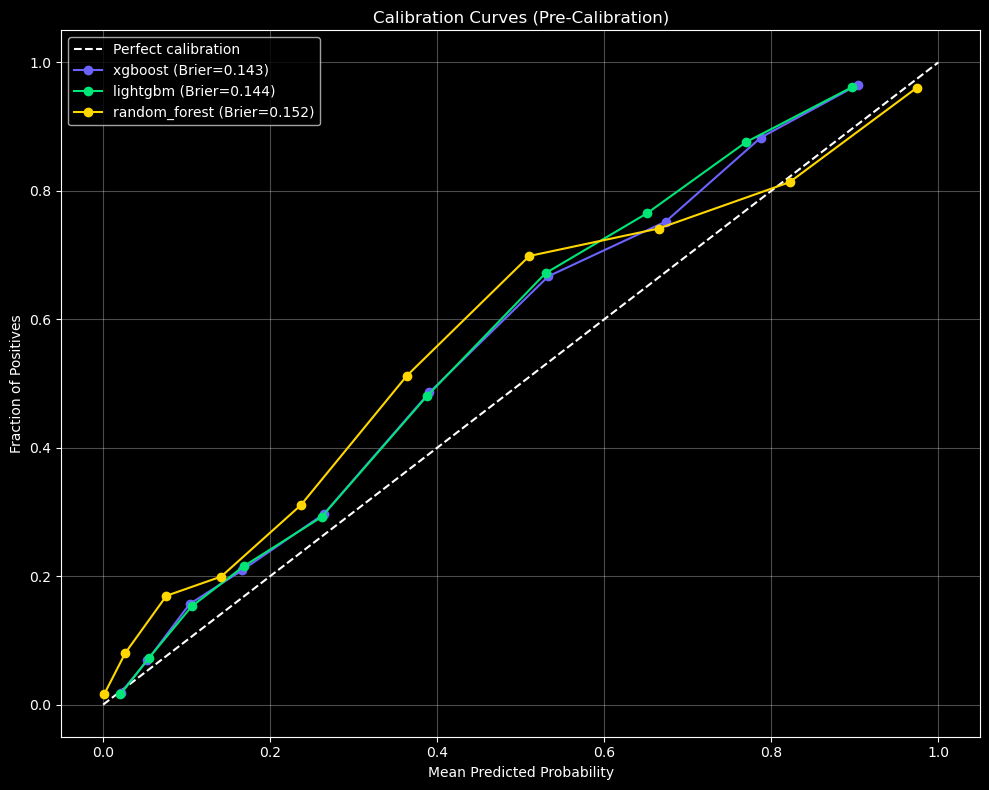

✅ Saved: charts/calibration_pre.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'w--', label='Perfect calibration')
colors = ['#6C63FF', '#00E676', '#FFD700']

for (name, model), color in zip(tuned_models.items(), colors):
    prob = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, prob)
    ax.plot(mean_pred, frac_pos, marker='o', color=color, label=f'{name} (Brier={brier:.3f})')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves (Pre-Calibration)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/calibration_pre.png', dpi=150)
plt.show()
print('✅ Saved: charts/calibration_pre.png')

## 5.2 Apply Calibration Methods

In [5]:
calibrated_models = {}
cal_results = []

for name, model in tuned_models.items():
    print(f'\nCalibrating: {name}')

    # Method 1: Isotonic
    cal_iso = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
    cal_iso.fit(X_test, y_test)
    prob_iso = cal_iso.predict_proba(X_test)[:, 1]
    brier_iso = brier_score_loss(y_test, prob_iso)

    # Method 2: Sigmoid (Platt scaling)
    cal_sig = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')
    cal_sig.fit(X_test, y_test)
    prob_sig = cal_sig.predict_proba(X_test)[:, 1]
    brier_sig = brier_score_loss(y_test, prob_sig)

    # Original
    prob_orig = model.predict_proba(X_test)[:, 1]
    brier_orig = brier_score_loss(y_test, prob_orig)

    print(f'  Original:  {brier_orig:.4f}')
    print(f'  Isotonic:  {brier_iso:.4f}')
    print(f'  Sigmoid:   {brier_sig:.4f}')

    if brier_iso <= brier_sig:
        best_cal = cal_iso; best_method = 'isotonic'; best_brier = brier_iso
    else:
        best_cal = cal_sig; best_method = 'sigmoid'; best_brier = brier_sig

    calibrated_models[name] = best_cal
    cal_results.append({'model': name, 'original_brier': brier_orig, 'calibrated_brier': best_brier, 'method': best_method, 'improvement': brier_orig - best_brier})
    with open(f'model/calibrated_{name}.pkl', 'wb') as f:
        pickle.dump(best_cal, f)
    print(f'  ✅ Saved calibrated_{name}.pkl')

cal_df = pd.DataFrame(cal_results)
print('\n=== CALIBRATION RESULTS ===')
print(cal_df.to_string(index=False))


Calibrating: xgboost
  Original:  0.1427
  Isotonic:  0.1366
  Sigmoid:   0.1389
  ✅ Saved calibrated_xgboost.pkl

Calibrating: lightgbm
  Original:  0.1437
  Isotonic:  0.1363
  Sigmoid:   0.1387
  ✅ Saved calibrated_lightgbm.pkl

Calibrating: random_forest
  Original:  0.1524
  Isotonic:  0.1427
  Sigmoid:   0.1470
  ✅ Saved calibrated_random_forest.pkl

=== CALIBRATION RESULTS ===
        model  original_brier  calibrated_brier   method  improvement
      xgboost        0.142716          0.136566 isotonic     0.006150
     lightgbm        0.143739          0.136332 isotonic     0.007408
random_forest        0.152388          0.142732 isotonic     0.009655


## 5.3 Post-Calibration Curves

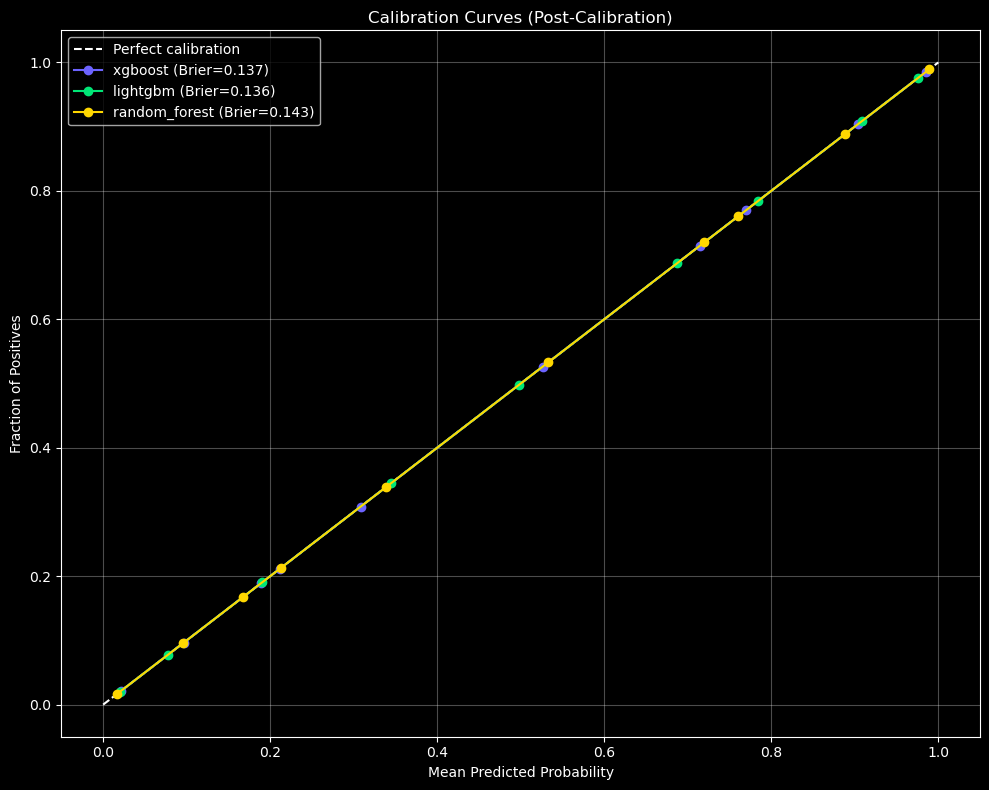

✅ Saved: charts/calibration_curve.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'w--', label='Perfect calibration')
colors = ['#6C63FF', '#00E676', '#FFD700']

for (name, model), color in zip(calibrated_models.items(), colors):
    prob = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, prob)
    ax.plot(mean_pred, frac_pos, marker='o', color=color, label=f'{name} (Brier={brier:.3f})')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves (Post-Calibration)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/calibration_curve.png', dpi=150)
plt.show()
print('✅ Saved: charts/calibration_curve.png')